In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('Amazon Sale Report.csv', low_memory=False)
print('Shape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())

Shape: (128975, 24)

Missing Values:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64


In [3]:
df.drop(columns=['index', 'Unnamed: 22', 'promotion-ids',
                 'fulfilled-by', 'ASIN', 'SKU'],
        inplace=True, errors='ignore')

df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

df.columns = (df.columns.str.strip()
                        .str.lower()
                        .str.replace(' ', '_')
                        .str.replace('-', '_'))

df.dropna(subset=['amount'], inplace=True)
df['courier_status'] = df['courier_status'].fillna('Unknown')
df['ship_postal_code'] = df['ship_postal_code'].astype(str)
df['month'] = df['date'].dt.month_name()
df['month_num'] = df['date'].dt.month
df['is_cancelled'] = (df['status'] == 'Cancelled').astype(int)
df['ship_city'] = df['ship_city'].str.upper()

print('Cleaned shape:', df.shape)

Cleaned shape: (121180, 21)


In [4]:
# Q1 Revenue by Category
cat_revenue = df.groupby('category')['amount'].sum().sort_values(ascending=False)
print('Revenue by Category:')
print(cat_revenue)

# Q2 Top 10 States
state_orders = df.groupby('ship_state')['order_id'].count().sort_values(ascending=False).head(10)
print('\nTop 10 States:')
print(state_orders)

# Q3 Monthly Trend
monthly = df.groupby(['month_num','month'])['amount'].sum().reset_index().sort_values('month_num')
print('\nMonthly Revenue:')
print(monthly)

# Q4 Order Status
print('\nOrder Status:')
print(df['status'].value_counts())

# Q5 B2B vs B2C
print('\nB2B vs B2C Revenue:')
print(df.groupby('b2b')['amount'].sum())
print('\nB2B vs B2C Orders:')
print(df.groupby('b2b')['order_id'].count())

# Q6 Fulfilment
print('\nFulfilment Revenue:')
print(df.groupby('fulfilment')['amount'].sum())

# Q7 Top Cities
print('\nTop 10 Cities:')
print(df.groupby('ship_city')['order_id'].count().sort_values(ascending=False).head(10))

Revenue by Category:
category
Set             39204124.03
kurta           21299546.70
Western Dress   11216072.69
Top              5347792.30
Ethnic Dress      791217.66
Blouse            458408.18
Bottom            150667.98
Saree             123933.76
Dupatta              915.00
Name: amount, dtype: float64

Top 10 States:
ship_state
MAHARASHTRA       21073
KARNATAKA         16394
TAMIL NADU        10809
TELANGANA         10637
UTTAR PRADESH      9947
DELHI              6393
KERALA             6151
WEST BENGAL        5547
ANDHRA PRADESH     5055
HARYANA            4188
Name: order_id, dtype: int64

Monthly Revenue:
   month_num  month      amount
0          3  March   101683.85
1          4  April 28838708.32
2          5    May 26226476.75
3          6   June 23425809.38

Order Status:
status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                97

In [5]:
aov = df.groupby('category')['amount'].mean().sort_values(ascending=False)
cancel = df[df['status']=='Cancelled'].groupby('category')['order_id'].count()
total = df.groupby('category')['order_id'].count()
cancel_rate = (cancel/total*100).sort_values(ascending=False)
size_rev = df.groupby('size')['amount'].sum().sort_values(ascending=False)

print('AOV by Category:')
print(aov)
print('\nCancellation Rate %:')
print(cancel_rate)
print('\nRevenue by Size:')
print(size_rev)

AOV by Category:
category
Set             833.39
Saree           799.57
Western Dress   762.79
Ethnic Dress    723.90
Top             526.10
Blouse          520.33
kurta           455.93
Bottom          358.73
Dupatta         305.00
Name: amount, dtype: float64

Cancellation Rate %:
category
Bottom          9.76
Western Dress   9.08
kurta           8.98
Set             8.93
Blouse          8.51
Top             8.16
Saree           7.74
Ethnic Dress    7.32
Dupatta          NaN
Name: order_id, dtype: float64

Revenue by Size:
size
M      13906754.37
L      13234886.19
XL     12464965.86
XXL    10636288.45
S      10629210.18
3XL     9157147.68
XS      7022375.20
6XL      576249.33
5XL      425156.63
4XL      334451.64
Free     205192.77
Name: amount, dtype: float64


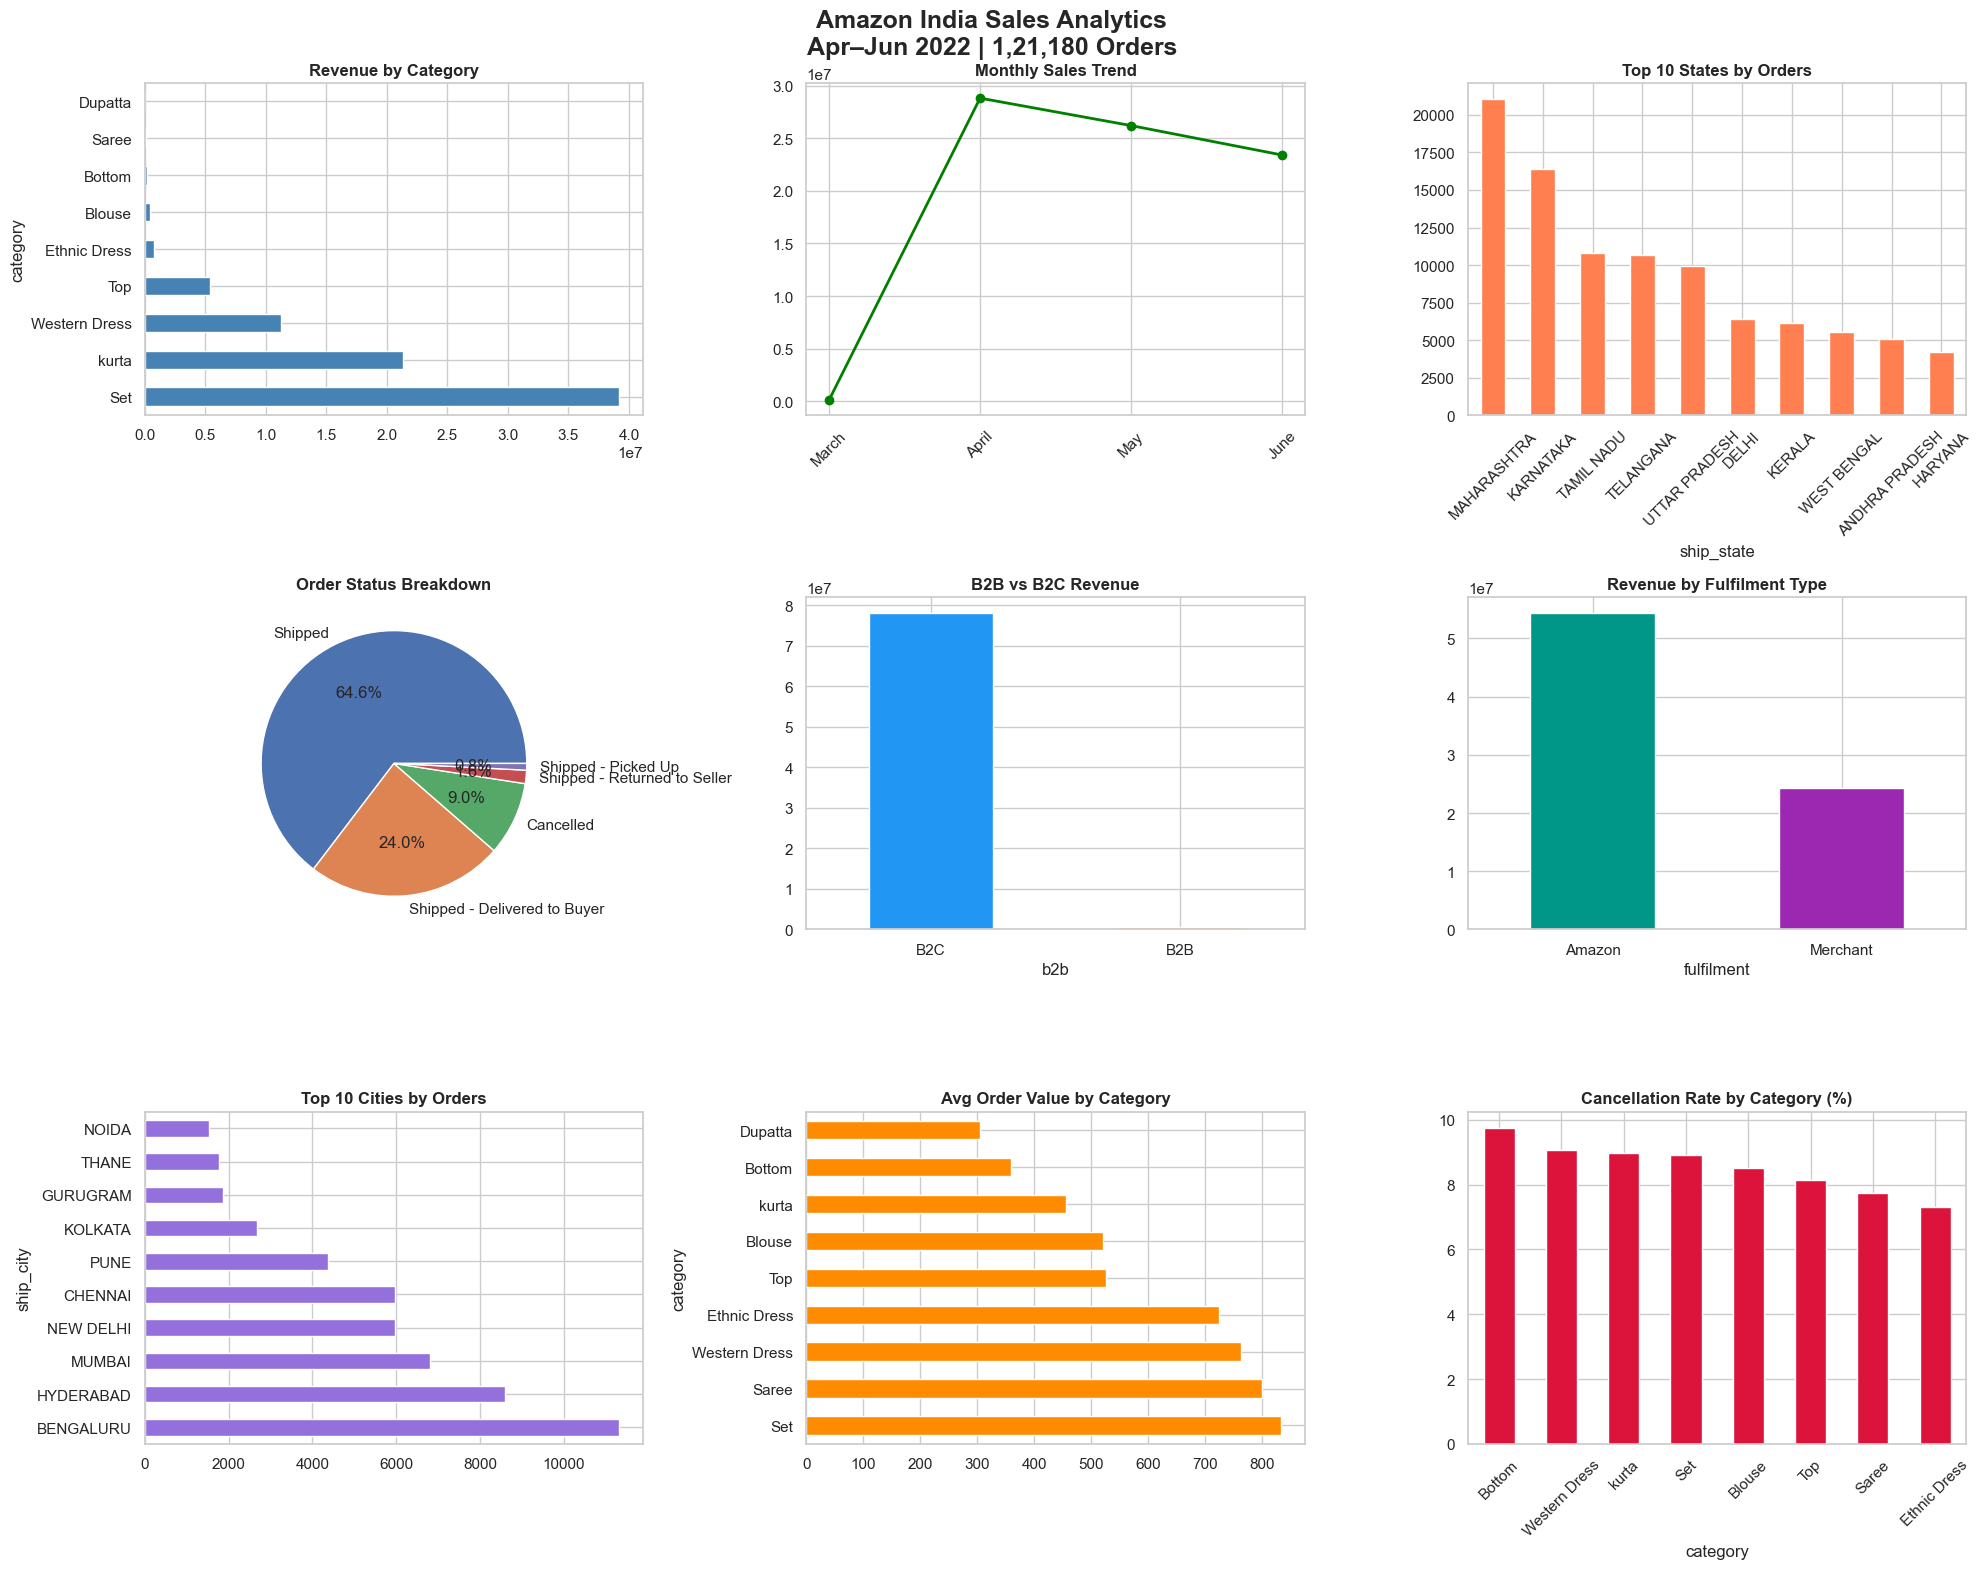

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Amazon India Sales Analytics\nApr–Jun 2022 | 1,21,180 Orders',
             fontsize=18, fontweight='bold')

cat_revenue.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Revenue by Category', fontweight='bold')

axes[0,1].plot(monthly['month'], monthly['amount'],
               marker='o', color='green', linewidth=2)
axes[0,1].set_title('Monthly Sales Trend', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

state_orders.plot(kind='bar', ax=axes[0,2], color='coral')
axes[0,2].set_title('Top 10 States by Orders', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=45)

df['status'].value_counts().head(5).plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Order Status Breakdown', fontweight='bold')
axes[1,0].set_ylabel('')

df.groupby('b2b')['amount'].sum().plot(kind='bar', ax=axes[1,1],
                                        color=['#2196F3','#FF9800'])
axes[1,1].set_title('B2B vs B2C Revenue', fontweight='bold')
axes[1,1].set_xticklabels(['B2C','B2B'], rotation=0)

df.groupby('fulfilment')['amount'].sum().plot(kind='bar', ax=axes[1,2],
                                               color=['#009688','#9C27B0'])
axes[1,2].set_title('Revenue by Fulfilment Type', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=0)

df.groupby('ship_city')['order_id'].count().sort_values(ascending=False).head(10).plot(
    kind='barh', ax=axes[2,0], color='mediumpurple')
axes[2,0].set_title('Top 10 Cities by Orders', fontweight='bold')

aov.plot(kind='barh', ax=axes[2,1], color='darkorange')
axes[2,1].set_title('Avg Order Value by Category', fontweight='bold')

cancel_rate.dropna().plot(kind='bar', ax=axes[2,2], color='crimson')
axes[2,2].set_title('Cancellation Rate by Category (%)', fontweight='bold')
axes[2,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('amazon_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
amazon_fulfil = df[df['fulfilment']=='Amazon']['amount']
merchant_fulfil = df[df['fulfilment']=='Merchant']['amount']

t_stat, p_value = stats.ttest_ind(amazon_fulfil, merchant_fulfil)

print('=== Hypothesis Test: Fulfilment Type vs Revenue ===')
print(f'Amazon Mean AOV: ₹{amazon_fulfil.mean():.2f}')
print(f'Merchant Mean AOV: ₹{merchant_fulfil.mean():.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')
if p_value < 0.05:
    print('REJECT H0 — Significant difference exists')
else:
    print('FAIL TO REJECT H0 — No significant difference')

=== Hypothesis Test: Fulfilment Type vs Revenue ===
Amazon Mean AOV: ₹649.48
Merchant Mean AOV: ₹646.51
T-statistic: 1.7037
P-value: 0.088444
FAIL TO REJECT H0 — No significant difference


In [8]:
print('=== Project Summary ===')
print(f'Total Orders: {len(df):,}')
print(f'Total Revenue: ₹{df["amount"].sum():,.2f}')
print(f'Avg Order Value: ₹{df["amount"].mean():.2f}')
print(f'Cancellation Rate: {df["is_cancelled"].mean()*100:.2f}%')
print(f'Date Range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Categories: {df["category"].nunique()}')
print(f'States: {df["ship_state"].nunique()}')

=== Project Summary ===
Total Orders: 121,180
Total Revenue: ₹78,592,678.30
Avg Order Value: ₹648.56
Cancellation Rate: 8.88%
Date Range: 2022-03-31 to 2022-06-29
Categories: 9
States: 68
